# Airbnb Price Prediction
#### By Damiru Vidunitha Wanniarachchi (S4137361)

### How to Run:
1. Install required libraries
2. Place `train_data.csv` and `test_data.csv` in `dataset` folder in the same directory
3. Run all cells sequencially

## 1.0 Imports and Setup

In [1]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib seaborn scikit-learn scipy


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip3.11 install --upgrade pip


In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, PowerTransformer, FunctionTransformer, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error

## 2.0 Dataset

Loading the training and test datasets provided on Canvas. The training dataset includes the target variable `price` whereas the test dataset does not.

## 2.1 Load Dataset

In [3]:
# dataframes
df_tr = pd.read_csv('dataset/train_data.csv')
df_te = pd.read_csv('dataset/test_data.csv')

## 2.2 Exploratory Data Analysis

### Understanding the data

In [4]:
df_tr.head()

,host_is_superhost,city,country,latitude,longitude,room_type,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,instant_bookable,calculated_host_listings_count
0,f,Kingston,Australia,-38.022565,145.098937,Entire home/apt,5,1.0,2.0,4.0,111,3,28,94.0,t,1
1,f,Yarra,Australia,-37.782125,144.988079,Entire home/apt,3,1.0,1.0,1.0,80,1,59,93.0,t,1
2,t,Port Phillip,Australia,-37.853710,144.981529,Entire home/apt,4,1.0,1.0,2.0,150,2,14,100.0,f,1
3,f,Glen Eira,Australia,-37.876393,145.036635,Entire home/apt,2,1.0,1.0,1.0,125,1,39,97.0,f,55
4,f,Melbourne,Australia,-37.810398,144.950113,Entire home/apt,3,1.0,1.0,2.0,79,3,7,97.0,t,1


In [5]:
df_tr.info()

<class 'pandas.DataFrame'>
RangeIndex: 8586 entries, 0 to 8585
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   host_is_superhost               8586 non-null   str    
 1   city                            8586 non-null   str    
 2   country                         8586 non-null   str    
 3   latitude                        8586 non-null   float64
 4   longitude                       8586 non-null   float64
 5   room_type                       8586 non-null   str    
 6   accommodates                    8586 non-null   int64  
 7   bathrooms                       8586 non-null   float64
 8   bedrooms                        8586 non-null   float64
 9   beds                            8586 non-null   float64
 10  price                           8586 non-null   int64  
 11  minimum_nights                  8586 non-null   int64  
 12  number_of_reviews               8586 non-null

In [6]:
df_tr.describe()

,latitude,longitude,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,number_of_reviews,review_scores_rating,calculated_host_listings_count
count,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000,8586.000000
mean,-37.825074,145.009374,3.559865,1.282320,1.533077,2.036222,139.771372,3.158747,27.946657,94.176101,7.427324
std,0.065145,0.130473,2.225801,0.557906,0.916369,1.544967,123.293376,20.788007,42.409812,8.471527,15.438001
min,-38.224427,144.531993,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,20.000000,1.000000
25%,-37.849202,144.957065,2.000000,1.000000,1.000000,1.000000,71.000000,1.000000,3.000000,92.000000,1.000000
50%,-37.816460,144.977004,3.000000,1.000000,1.000000,2.000000,115.000000,2.000000,11.000000,97.000000,1.000000
75%,-37.802849,145.008316,4.000000,1.500000,2.000000,2.000000,162.750000,3.000000,33.000000,100.000000,5.000000
max,-37.491059,145.760250,16.000000,9.000000,10.000000,18.000000,3000.000000,1000.000000,479.000000,100.000000,98.000000


The dataset contains 8586 listing and 16 features. As it is indicated above, the dataset has non-null values for all the entries for all the columns, so **no missing data** in present.

Some numerical features such as `Price`, `minimum_nights`indicate varying ranges and distributions.
For example, `Price` has a *mean* of ~139.77 whereas it ranges from a minimum of 0 to 3000 showing a **right-skewed distribution**. This suggests that there's a small number of high-priced house listings that may influence the overall distribution.

### Feature Types

In [7]:
# binary features for binary encoding
ft_bin = ['host_is_superhost', 'instant_bookable']

# categorical features for one-hot encoding
ft_cat = ['city', 'country', 'room_type']

# Numerical features (excluding price)
ft_num = ['latitude', 'longitude', 'accommodates', 'bathrooms', 
                'bedrooms', 'beds', 'minimum_nights',
                'number_of_reviews', 'review_scores_rating', 
                'calculated_host_listings_count']

### Distribution of Price

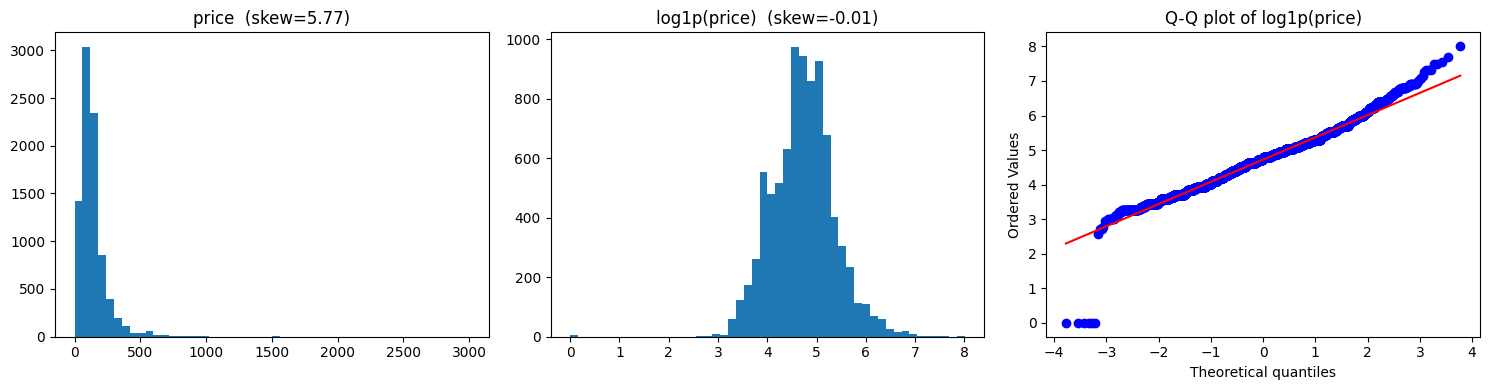

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# raw price
axes[0].hist(df_tr['price'], bins=50)
axes[0].set_title(f'price  (skew={df_tr["price"].skew():.2f})')

# log price
price_log = np.log1p(df_tr['price']) # log1p: safer handling zeros
axes[1].hist(price_log, bins=50)
axes[1].set_title(f'log1p(price)  (skew={price_log.skew():.2f})')

# q-q plot
stats.probplot(price_log, dist="norm", plot=axes[2])
axes[2].set_title('Q-Q plot of log1p(price)')

plt.tight_layout()

As we deducted before, the *raw price distribution* is **strongly right-skewed (skweness = $5.77$)** where the vast majority of the prices lie within the **$0-500$** range indicating that most listings are relatively affordable with a small number of high-priced *outliers.* This *violates homoscedasticity* of linear regression (**heteroscedasticity**) where error variances across data are unequal, making the high-priced listings *disproportionately influencial*. However, after applying *log1p* the skewness has been **reduced to $-0.01$** producing a more symmetric distribution suitable for linear models.

The *Q-Q plot* showcases the *quantiles of the transformed data vs a normal distribution* incidcating that the transformed data follows a normal distribution with *minor deviation* on the tail consistent with the few extreme-priced listings remaining in the data, further *strengthening the transformation*.

### Missing values

In [9]:
print(df_tr.isnull().sum()[df_tr.isnull().sum() > 0])

Series([], dtype: int64)


The above check for *null values(**NaNs**)* revealed that there're no missing values of the training dataset.

However, further investigation for *$0* listings (`price`) should be conducted as these outliers could provide *false signals* to the model.

In [10]:
print(f"Number of $0 listings: {(df_tr['price'] <= 0).sum()}")

Number of $0 listings: 6


These $\$0$ listings should be handled accordingly during **Data Preprocessing**.

### Numerical Features vs. Log(Price)

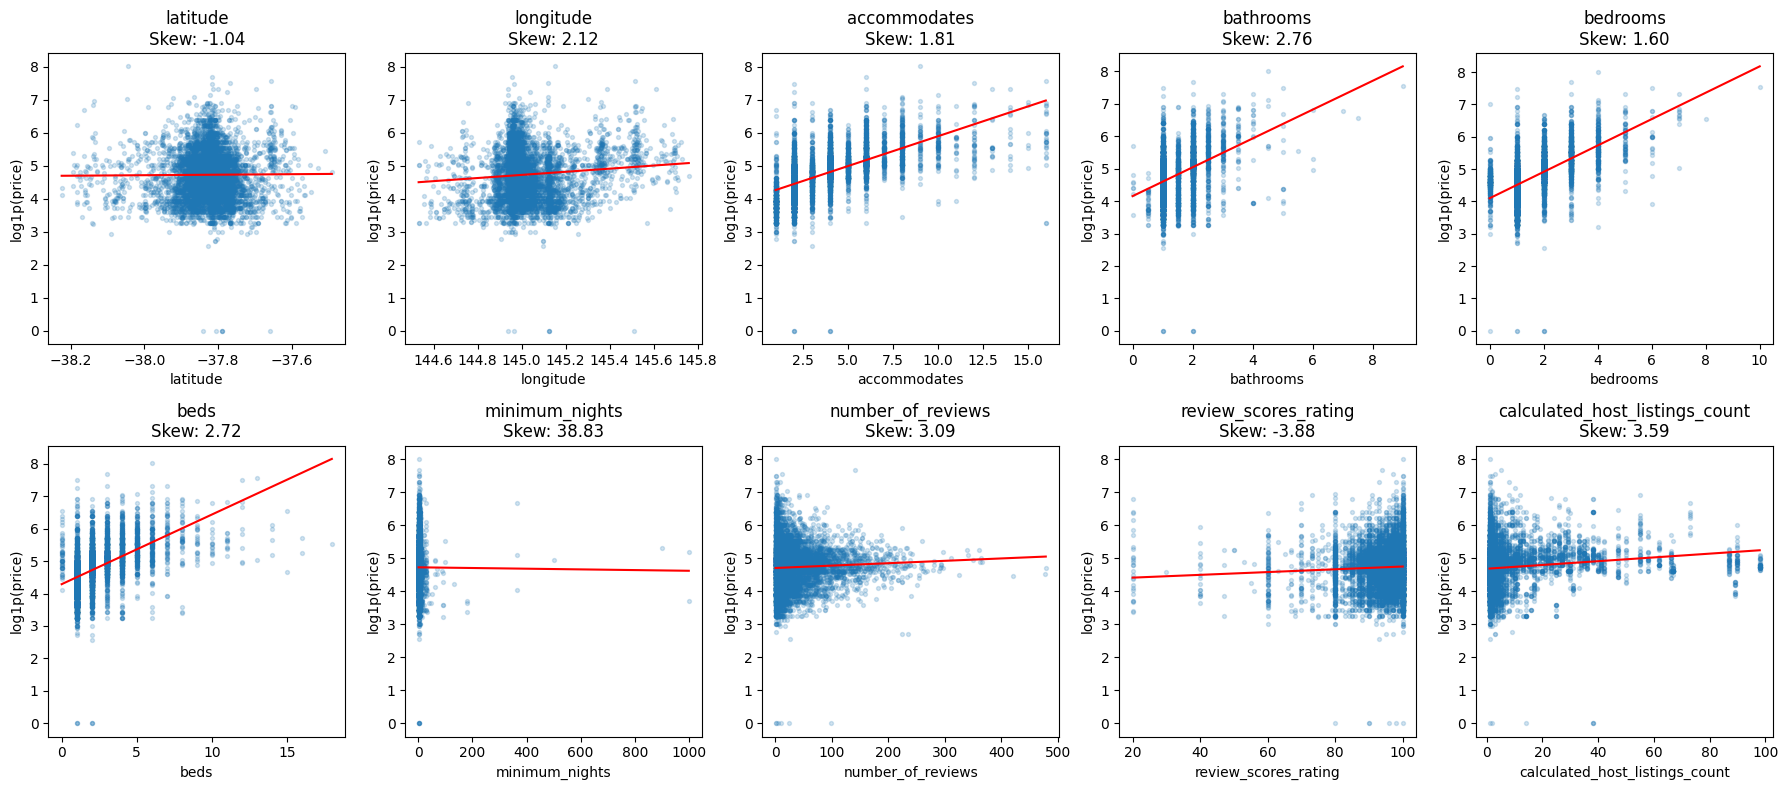

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for ax, feat in zip(axes.flatten(), ft_num):
    ax.scatter(df_tr[feat], np.log1p(df_tr['price']), alpha=0.2, s=8)
    ax.set_title(f'{feat}\nSkew: {df_tr[feat].skew():.2f}')
    ax.set_xlabel(feat)
    ax.set_ylabel('log1p(price)')
    
    # regression line to see linear trend
    m, b = np.polyfit(df_tr[feat].fillna(df_tr[feat].median()), np.log1p(df_tr['price']), 1)
    x_line = np.linspace(df_tr[feat].min(), df_tr[feat].max(), 100)
    ax.plot(x_line, m*x_line + b, 'r-', linewidth=1.5)
    
plt.tight_layout()

Features such as `accommodates`, `bathrooms`, `bedrooms`, and `beds` show *positive linear trends* with *log1p(price)*, indicating that larger, better-equipped listings tend to have higher prices. They also showcase some *skewness* to the right.

Other numerical features showcase weaker relationships:

- `latitude` and `longitude` are mostly flat, with data clustered to the middle of the ranges which are *melbourne inner suburbs*.

- `minimum_nights` is *heavily right-skewed*(skew=$38.83$), with most listings are near zero, showing small linear trend.
- `number_of_reviews`(skew=$3.09$) and `calculated_host_listings_count`(skew=$3.59$) also show *right-skewed distribution* eventhough not as heavy with *linear trends*.
- `review_scores_rating` shows a *left-skewed distribution*(skew=$-3.88$) indicating most listings got higher review ratings which limits discriminative power.

Overall, the *log transformation* stablizes *residual variance* across prices (*homoscedasticity*) and enhances existing *linear trends*, making data more *suitable* for the models. In short, `log1p(price)` proves to be a better target for *regression models*. 

### Categorical Features vs. Log(Price)

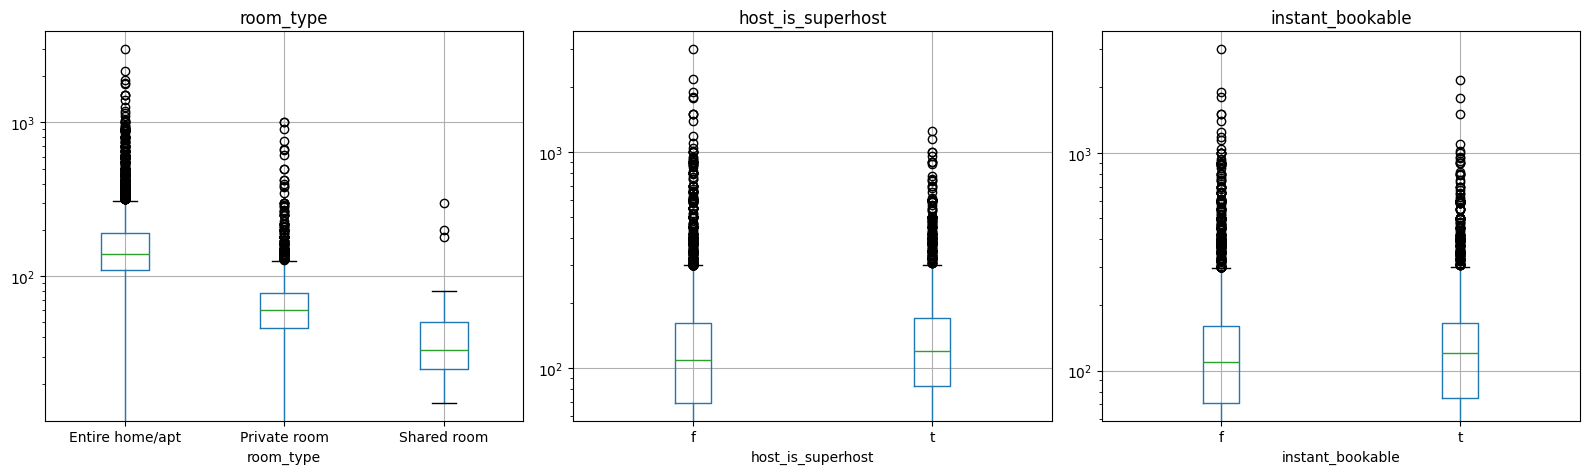

In [12]:
# load training data again to access original data
df_tr_original = pd.read_csv('dataset/train_data.csv')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, feat in zip(axes, ['room_type', 'host_is_superhost', 'instant_bookable']):
    df_tr_original.boxplot(column='price', by=feat, ax=ax)
    ax.set_yscale('log')  # log scale on y so you can actually see the boxes
    ax.set_title(feat)
plt.suptitle('')
plt.tight_layout()

`room_type` feature shows strong grouping across all three types, with differing medians. This feature is *one-hot encoded* and is expected to have *high coeficient magnitude* in all models. Most of the *outliers (high-priced listings)* are very concentrated within the 'Entire home/apt' and 'Private room' agreeing to the nature of luxury rentals.

`host_is_superhost` however, shows minimal differetiation of prices with median prices being nearly identical across both types. This suggests that `host_is_superhost` does not command a higher price in the dataset. Therefore, this feature may contribute *less* to model performance. As for *outlier density and range* of this feature, moderate difference is present, but not significant enough to support that `host_is_superhost` feature drive the price of listings.

`instant_bookable` too shows minimal differentiation of prices with almost identical medians. The *outlier density* of the types are nearly identical suggesting that this feature does not have considerable influence on prices of listings as well.

### Correlation Heatmap

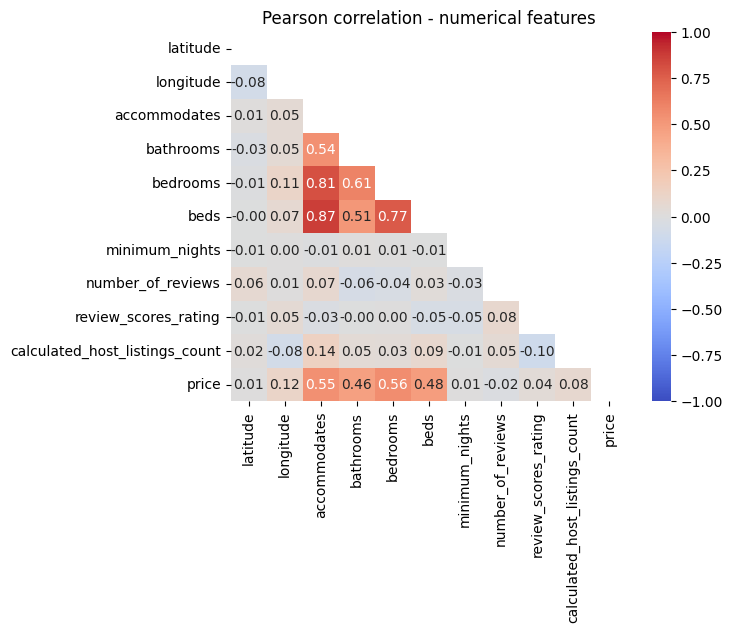

In [13]:
corr = df_tr[ft_num + ['price']].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # upper triangle only

sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1)
plt.title('Pearson correlation - numerical features')
plt.show()

The pearson correlation heatmap above, shows that features related to the *physical capacity of Airbnbs* such as `accommodates` ($0.55$), `bedrooms` ($0.56$) indicate the strongest positive linear relationship with *price*.

However, it is also clear that significant **multicolinearity** is present between `beds`/`accommodates` ($0.87$), `bedrooms`/`accommodates` ($0.81$), and `beds`/`bedrooms` ($0.77$). In *Ordinary Least Squares (ols)*, multicolinearity inflates *coefficient varience* where even small changes in data could produce large changes in individual coefficients. This problem directly motivates **Ridge Regression** where large coefficients are penalised which would stabalise the model.

Interestingly, *marketing and behavioural metrics* such as `number_of_reviews`, `reviews_scores_rating`, and `minimum_nights` showcase weaker, negligible correlation with *price*. Since, Pearson correlation only captures linear correlations, these features may contribute indirectly as a combination with other features. To automatically discard features that adds no signal at all, **Lasso Regression** could be applied where the model would shrink the *non-informative feature coefficients* to zero (implicit *feature selection*).

## 2.3 Data Preprocessing

### Data Cleaning

The previous EDA identified a few $\$0$ listings ($n=6$). To ensure that the model stays focused, these rows would be removed from the *training dataframe*.

In [24]:
# create mask for valid prices
df_tr = df_tr[df_tr['price'] > 0].copy()

# verify there're no $0 listings
print(f"Number of $0 listings: {(df_tr['price'] <= 0).sum()}")

Number of $0 listings: 0


### Transformation Pipeline

In order to centralise out data preprocessing logic, maintain consistency, and handle different data types, a `ColumnTransformer` is implemented.

**Log1p**: The logarithmic transformation is applied to *eligible right-skewed numerical features* (`minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`) to ensure stable variance and to normalise the distribution. The other features (`accommodates`, `bathrooms`, `bedrooms`, `beds`) were deemed *ineligible* as they are *descrete counts* and keeping as-is provides better interpretability.

**Yeo-Johnson**: Used for the left-skewed feature `review_scores_rating` via Scikit-Learns's `PowerTransformer` as standard Log transformation is ineffective in handling extreme negative skewness.

**One-Hot Encoding**: Used for categorical features (`city`, `country`, `room_type`) since machine learning models cannot work directly with strings. `drop='first'` is used to avoid the *Dummy variable trap* (Multicolinearity).

**StandardScalar**: Applied to all numerical features ('latitude', 'longitude', 'accommodates', 'bathrooms', 
                'bedrooms', 'beds', 'minimum_nights',
                'number_of_reviews', 'review_scores_rating', 
                'calculated_host_listings_count')

In [23]:
# binary encoding
map_bool = {'t': 1, 'f': 0, True: 1, False: 0}
for col in ['host_is_superhost', 'instant_bookable']:
    df_tr[col] = df_tr[col].map(map_bool)
    df_te[col] = df_te[col].map(map_bool)

### Transformations on skewed features

Exploratory Data Analysis (EDA) identified a number of *right-skewed* numerical features which are `price`, `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`, `accommodates`, `bathrooms`, `bedrooms`, and `beds` as well as one *left-skewed* feature `review_scores_rating`.

The right-skewed features' long tail could be compressed to improve linarity by applying `log1p`. However, some of these features are **descrete counts** (`accommodates`, `bathrooms`, `bedrooms`, `beds`) and therefore, will be kept as-is for better interpretability. But the rest of the right-skewed features (`price`, `minimum_nights`, `number_of_reviews`, `calculated_host_listings_count`) would be transformed with `log1p`.

The left-skewed feature `review_scores_rating` would be applied the **Yeo-Johnson transformation** via Scikit-Learns's `PowerTransformer` as it effectively handles negative skewness.

## 3.0 Model Development

## 3.1 Train/Validation Data Split

In [22]:
# Features and target
X = df_tr.drop(columns=['price', 'latitude', 'longitude'])
y = np.log1p(df_tr['price'])
X_test_raw = df_te.drop(columns=['latitude', 'longitude'])

# Feature groups
ft_bin = ['host_is_superhost', 'instant_bookable']
ft_cat = ['city', 'country', 'room_type']
ft_log = ['minimum_nights', 'number_of_reviews', 
          'calculated_host_listings_count']
ft_yeo = ['review_scores_rating']
ft_num = ['accommodates', 'bathrooms', 'bedrooms', 'beds']

# Pipelines for groups needing transform + scale
log_pipeline = Pipeline([
    ('log',   FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

yeo_pipeline = Pipeline([
    ('yeo',   PowerTransformer(method='yeo-johnson')),
    ('scale', StandardScaler())
])

preprocessor = ColumnTransformer(transformers=[
    ('bin', StandardScaler(),                                              ft_bin),
    ('log', log_pipeline,                                                  ft_log),
    ('yeo', yeo_pipeline,                                                  ft_yeo),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore',
                          sparse_output=False),                            ft_cat),
    ('num', StandardScaler(),                                              ft_num)
])

# SPLIT FIRST — then fit preprocessor on train only
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train = preprocessor.fit_transform(X_train_raw)
X_val   = preprocessor.transform(X_val_raw)
X_test  = preprocessor.transform(X_test_raw)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (6864, 41), Val: (1716, 41), Test: (8585, 41)
